<style>
.note-card{border:1px solid #dbe3ef;border-radius:18px;padding:18px 20px;background:linear-gradient(135deg,#ffffff 0%,#f8fbff 100%);box-shadow:0 10px 26px rgba(0,0,0,.05);margin:12px 0;}
.warn-card{border:1px solid #fed7aa;border-radius:18px;padding:16px 18px;background:linear-gradient(135deg,#fff7ed 0%,#fffbeb 100%);margin:12px 0;}
.good-card{border:1px solid #bbf7d0;border-radius:18px;padding:16px 18px;background:linear-gradient(135deg,#f0fdf4 0%,#ecfdf5 100%);margin:12px 0;}
</style>


<div style="display:flex;justify-content:center;margin:10px 0 18px 0;">
<div style="max-width:1180px;width:100%;border:1px solid #d1d5db;border-radius:24px;padding:34px 42px;background:linear-gradient(135deg,#f8fafc 0%,#eff6ff 45%,#f0fdf4 100%);box-shadow:0 16px 36px rgba(0,0,0,.07);font-family:Segoe UI,Arial,sans-serif;">
<div style="text-align:center;">
<div style="font-size:14px;letter-spacing:1.2px;color:#2563eb;font-weight:800;">PROYECTO FINAL · INTELIGENCIA ARTIFICIAL</div>
<h1 style="margin:10px 0 6px 0;font-size:36px;color:#0f172a;">Sistema Inteligente Híbrido para Planificación Académica Adaptativa</h1>
<p style="margin-top:16px;color:#475569;font-size:16px;">Aprendizaje supervisado + CSP + razonamiento probabilístico + MDP</p>
</div>
</div>
</div>

<p align="center"><img src="proyecto_final_mejorado_assets/01_pipeline_hibrido.png" width="960"/></p>

<div class="good-card"><b>Modo rápido por defecto.</b> Este notebook evita entrenamientos de una hora: usa muestreo, límites de tiempo, modelos eficientes y redes neuronales desactivadas por defecto.</div>


# 1. Objetivo del proyecto

Construir un sistema inteligente híbrido que apoye decisiones de planificación académica. El flujo general es:

<p align="center"><img src="proyecto_final_mejorado_assets/gif_01_pipeline_hibrido.gif" width="850"/></p>

1. Estimar riesgo académico con aprendizaje supervisado.
2. Convertir el riesgo en demanda esperada por módulo.
3. Generar un horario factible usando un CSP.
4. Estimar riesgo operativo del horario.
5. Elegir acciones de replanificación mediante un MDP.

La propuesta es híbrida porque no depende de un único modelo: combina predicción, búsqueda, probabilidad y toma de decisiones secuenciales.


# 2. Formulación matemática

Sea $x_i\in\mathbb{R}^d$ el vector de características del estudiante $i$ y $y_i\in\{0,1\}$:

$$
y_i =
\begin{cases}
1,&\text{estudiante en riesgo}\\
0,&\text{estudiante no en riesgo}
\end{cases}
$$

Un clasificador estima:

$$
\hat p_i=P(y_i=1\mid x_i).
$$

Para regresión logística:

$$
P(y_i=1\mid x_i)=\sigma(w^\top x_i+b),\qquad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

La demanda esperada de un módulo $m$ se aproxima como:

$$
D_m=\sum_{i\in m}(1-\hat p_i).
$$

Cada sección del horario es una variable CSP:

$$
X_j=(t_j,r_j,p_j),
$$

con restricciones:

$$
(t_i=t_j\land r_i=r_j)\Rightarrow i=j,\qquad
(t_i=t_j\land p_i=p_j)\Rightarrow i=j.
$$

La replanificación se modela con value iteration:

$$
V_{k+1}(s)=\max_a\sum_{s'}T(s,a,s')\left[R(s,a,s')+\gamma V_k(s')\right].
$$


## 3. Configuración Inicial
Importa todas las dependencias necesarias (Numpy, Pandas, Matplotlib, Scikit-learn) y define constantes críticas para el control de ejecución. Introduce funciones utilitarias para el cálculo de probabilidades de modelos y métricas robustas.

**Notas Importantes:**
- `FAST_MODE = True`: Indica que el script prioriza la velocidad, limitando filas (`MAX_ROWS_FAST = 12,000`).
- `TRAINING_TIME_BUDGET_SECONDS = 360`: Limita el tiempo de entrenamiento a 6 minutos.
- Funciones clave:
    - `model_probability`: Estandariza la obtención de probabilidades sin importar si el modelo usa `predict_proba` o `decision_function`.
    - `safe_auc`: Maneja errores de cálculo de AUC cuando solo hay una clase presente.
- `SEED = 42`: Asegura la reproducibilidad de los experimentos.


In [1]:
# ==========================================================
# 3. Configuración global
# ==========================================================
from pathlib import Path
import warnings, time, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from IPython.display import display, Image

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.inspection import permutation_importance

SEED = 42
rng = np.random.default_rng(SEED)

FAST_MODE = True
MAX_ROWS_FAST = 12_000
TRAINING_TIME_BUDGET_SECONDS = 360
RUN_SLOW_MODELS = False

DATA_CANDIDATES = [Path("data/oulad"), Path("data"), Path(".")]
ASSET_DIR = Path("proyecto_final_mejorado_assets")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14

def sigmoid(z):
    return 1/(1+np.exp(-z))

def safe_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan
    except Exception:
        return np.nan

def model_probability(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return sigmoid(model.decision_function(X))
    return model.predict(X).astype(float)

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

print("Modo rápido:", FAST_MODE)
print("Presupuesto de entrenamiento:", TRAINING_TIME_BUDGET_SECONDS, "segundos")


Modo rápido: True
Presupuesto de entrenamiento: 360 segundos


# 4. Carga de datos

El notebook busca OULAD en `data/oulad/`, `data/` o la carpeta actual. Si no lo encuentra, genera un dataset sintético reproducible con estructura similar. Esto permite presentar el proyecto sin depender de internet.


In [2]:
# ==========================================================
# 4.1 OULAD real o dataset sintético
# ==========================================================

def find_oulad_dir():
    """
    Busca automáticamente la carpeta donde está OULAD.
    Debe contener, como mínimo, studentInfo.csv.
    """
    for c in DATA_CANDIDATES:
        if (c / "studentInfo.csv").exists():
            return c
    return None


def safe_read_csv(path):
    """
    Lee archivos CSV de forma robusta.

    Correcciones incluidas:
    - Limpia nombres de columnas.
    - Trata valores raros como NaN.
    - Si el CSV viene separado por ';', lo detecta.
    """
    path = Path(path)

    if not path.exists():
        return None

    df = pd.read_csv(
        path,
        na_values=["?", "NA", "N/A", "nan", "NaN", "None", ""],
        low_memory=False
    )

    # Si por alguna razón el archivo se leyó como una sola columna,
    # intentamos con separador ';'.
    if df.shape[1] == 1:
        df = pd.read_csv(
            path,
            sep=";",
            na_values=["?", "NA", "N/A", "nan", "NaN", "None", ""],
            low_memory=False
        )

    df.columns = [str(c).strip() for c in df.columns]

    # Limpieza suave para columnas de texto
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan, "?": np.nan})

    return df


def to_numeric_safe(df, cols):
    """
    Convierte columnas a numérico sin romper el notebook.
    Si alguna columna no existe, la ignora.
    """
    for col in cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.replace(",", ".", regex=False)
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def load_oulad(data_dir):
    """
    Carga OULAD real y construye una tabla agregada por estudiante,
    módulo y presentación.

    Dataset base:
    - studentInfo.csv

    Agregados opcionales:
    - studentAssessment.csv + assessments.csv
    - studentVle.csv
    """

    # -------------------------------
    # 1. Información principal
    # -------------------------------
    df = safe_read_csv(data_dir / "studentInfo.csv")

    if df is None:
        raise FileNotFoundError("No se encontró studentInfo.csv")

    df = to_numeric_safe(df, [
        "id_student",
        "num_of_prev_attempts",
        "studied_credits"
    ])

    # -------------------------------
    # 2. Agregados de evaluaciones
    # -------------------------------
    assessments = safe_read_csv(data_dir / "assessments.csv")
    student_assessment = safe_read_csv(data_dir / "studentAssessment.csv")

    if assessments is not None and student_assessment is not None:

        assessments = to_numeric_safe(assessments, [
            "id_assessment",
            "date",
            "weight"
        ])

        student_assessment = to_numeric_safe(student_assessment, [
            "id_assessment",
            "id_student",
            "date_submitted",
            "is_banked",
            "score"
        ])

        ass = student_assessment.merge(
            assessments,
            on="id_assessment",
            how="left"
        )

        # Esta es la parte que corregía el error:
        # score y date_submitted deben ser numéricos antes de usar mean.
        ass = to_numeric_safe(ass, [
            "score",
            "date_submitted",
            "id_student"
        ])

        ass_agg = (
            ass
            .groupby(
                ["id_student", "code_module", "code_presentation"],
                dropna=False
            )
            .agg(
                mean_score=("score", "mean"),
                min_score=("score", "min"),
                max_score=("score", "max"),
                std_score=("score", "std"),
                assessments_submitted=("id_assessment", "count"),
                avg_submit_day=("date_submitted", "mean"),
                late_submit_rate=("date_submitted", lambda x: np.mean(x > 120))
            )
            .reset_index()
        )

        df = df.merge(
            ass_agg,
            on=["id_student", "code_module", "code_presentation"],
            how="left"
        )

    # -------------------------------
    # 3. Agregados de interacción VLE
    # -------------------------------
    student_vle = safe_read_csv(data_dir / "studentVle.csv")

    if student_vle is not None:

        student_vle = to_numeric_safe(student_vle, [
            "id_student",
            "id_site",
            "date",
            "sum_click"
        ])

        vle_agg = (
            student_vle
            .groupby(
                ["id_student", "code_module", "code_presentation"],
                dropna=False
            )
            .agg(
                total_clicks=("sum_click", "sum"),
                active_days=("date", "nunique"),
                avg_clicks_per_day=("sum_click", "mean"),
                max_clicks_day=("sum_click", "max"),
                std_clicks_day=("sum_click", "std")
            )
            .reset_index()
        )

        df = df.merge(
            vle_agg,
            on=["id_student", "code_module", "code_presentation"],
            how="left"
        )

    # -------------------------------
    # 4. Limpieza final de columnas numéricas agregadas
    # -------------------------------
    numeric_cols = [
        "mean_score",
        "min_score",
        "max_score",
        "std_score",
        "assessments_submitted",
        "avg_submit_day",
        "late_submit_rate",
        "total_clicks",
        "active_days",
        "avg_clicks_per_day",
        "max_clicks_day",
        "std_clicks_day"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def generate_synthetic_oulad_like(n=6000, seed=SEED):
    """
    Genera un dataset sintético estilo OULAD cuando no se encuentra
    el dataset real.
    """
    rng = np.random.default_rng(seed)

    modules = np.array(["AAA", "BBB", "CCC", "DDD", "EEE", "FFF", "GGG"])

    education = np.array([
        "No Formal quals",
        "Lower Than A Level",
        "A Level",
        "HE Qualification",
        "Post Graduate"
    ])

    df = pd.DataFrame({
        "id_student": np.arange(100000, 100000 + n),
        "code_module": rng.choice(
            modules,
            size=n,
            p=[.13, .16, .15, .14, .16, .12, .14]
        ),
        "code_presentation": rng.choice(["2013J", "2014B", "2014J"], size=n),
        "gender": rng.choice(["M", "F"], size=n),
        "region": rng.choice(
            ["East Anglian", "Scotland", "London", "North Western", "South", "Wales"],
            size=n
        ),
        "highest_education": rng.choice(
            education,
            size=n,
            p=[.06, .34, .37, .20, .03]
        ),
        "imd_band": rng.choice(
            [
                "0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
                "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"
            ],
            size=n
        ),
        "age_band": rng.choice(["0-35", "35-55", "55<"], size=n, p=[.71, .25, .04]),
        "num_of_prev_attempts": rng.poisson(.28, size=n).clip(0, 4),
        "studied_credits": rng.choice([30, 60, 90, 120], size=n, p=[.08, .58, .22, .12]),
        "disability": rng.choice(["N", "Y"], size=n, p=[.91, .09])
    })

    base_eng = rng.normal(0, 1, n)

    edu_bonus = df["highest_education"].map({
        "No Formal quals": -.8,
        "Lower Than A Level": -.35,
        "A Level": .1,
        "HE Qualification": .35,
        "Post Graduate": .55
    }).astype(float).values

    mod_diff = df["code_module"].map({
        "AAA": -.2,
        "BBB": .15,
        "CCC": .05,
        "DDD": .3,
        "EEE": -.05,
        "FFF": .25,
        "GGG": .1
    }).astype(float).values

    clicks_latent = base_eng + edu_bonus - .25 * mod_diff

    df["total_clicks"] = np.maximum(
        0,
        rng.lognormal(5.5 + .35 * clicks_latent, .65)
    ).astype(int)

    df["active_days"] = np.maximum(
        1,
        rng.normal(95 + 18 * clicks_latent, 25, n)
    ).astype(int).clip(1, 260)

    df["avg_clicks_per_day"] = df["total_clicks"] / df["active_days"]

    df["mean_score"] = np.clip(
        rng.normal(66 + 8 * edu_bonus + 7 * base_eng - 6 * mod_diff, 12),
        0,
        100
    )

    df["min_score"] = np.clip(
        df["mean_score"] - rng.uniform(5, 30, n),
        0,
        100
    )

    df["max_score"] = np.clip(
        df["mean_score"] + rng.uniform(3, 18, n),
        0,
        100
    )

    df["std_score"] = np.clip(
        rng.normal(8, 3, n),
        0,
        25
    )

    df["assessments_submitted"] = np.maximum(
        0,
        rng.poisson(5 + 1.2 * base_eng)
    ).clip(0, 12)

    df["avg_submit_day"] = np.clip(
        rng.normal(110 - 9 * base_eng + 6 * mod_diff, 35),
        1,
        260
    )

    df["late_submit_rate"] = np.clip(
        rng.normal(.25 + .15 * mod_diff - .08 * base_eng, .12),
        0,
        1
    )

    risk_logit = (
        -.55
        + .55 * df["num_of_prev_attempts"].values
        + .35 * (df["studied_credits"].values >= 90)
        + .7 * (df["disability"].values == "Y")
        + .45 * (df["highest_education"].values == "No Formal quals")
        + .3 * (df["highest_education"].values == "Lower Than A Level")
        + .65 * mod_diff
        - .018 * (df["mean_score"].values - 60)
        - .004 * (df["total_clicks"].values - np.median(df["total_clicks"].values))
        + .010 * (df["avg_submit_day"].values - 110)
        + rng.normal(0, .65, n)
    )

    risk_prob = sigmoid(risk_logit)
    adverse = rng.random(n) < risk_prob

    df["final_result"] = [
        rng.choice(["Fail", "Withdrawn"], p=[.58, .42]) if bad
        else ("Distinction" if score >= 82 and rng.random() < .55 else "Pass")
        for bad, score in zip(adverse, df["mean_score"].values)
    ]

    return df


oulad_dir = find_oulad_dir()

if oulad_dir:
    print("✅ OULAD encontrado:", oulad_dir.resolve())
    df = load_oulad(oulad_dir)
    DATA_MODE = "OULAD real"
else:
    print("⚠️ OULAD no encontrado. Se usa dataset sintético reproducible.")
    df = generate_synthetic_oulad_like(6000 if FAST_MODE else 25000)
    DATA_MODE = "Sintético reproducible"

print(DATA_MODE, df.shape)
display(df.head())

✅ OULAD encontrado: /Users/macbookproroberto/Downloads/Proyecto-Final_IA_Seccion_10_Grupo_1/data/oulad
OULAD real (32593, 24)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,max_score,std_score,assessments_submitted,avg_submit_day,late_submit_rate,total_clicks,active_days,avg_clicks_per_day,max_clicks_day,std_clicks_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,85.0,3.082207,5.0,112.4,0.4,934.0,40.0,4.765306,76.0,7.591224
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,70.0,4.335897,5.0,114.2,0.6,1435.0,80.0,3.337209,23.0,3.634240
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,NaN,NaN,NaN,NaN,NaN,281.0,12.0,3.697368,23.0,4.056336
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,88.0,6.892024,5.0,112.2,0.4,2158.0,123.0,3.254902,22.0,3.194577
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,75.0,20.513410,5.0,125.6,0.6,1034.0,70.0,2.937500,22.0,3.261895


# 5. Exploración inicial

Se revisa distribución del resultado, faltantes y módulos disponibles.


,columna,tipo,missing,missing_%
15,std_score,float64,9292,28.509189
12,mean_score,float64,6773,20.780536
13,min_score,float64,6773,20.780536
14,max_score,float64,6773,20.780536
18,late_submit_rate,float64,6750,20.709968
17,avg_submit_day,float64,6750,20.709968
16,assessments_submitted,float64,6750,20.709968
23,std_clicks_day,float64,3600,11.045316
19,total_clicks,float64,3365,10.324303
20,active_days,float64,3365,10.324303


,frecuencia
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


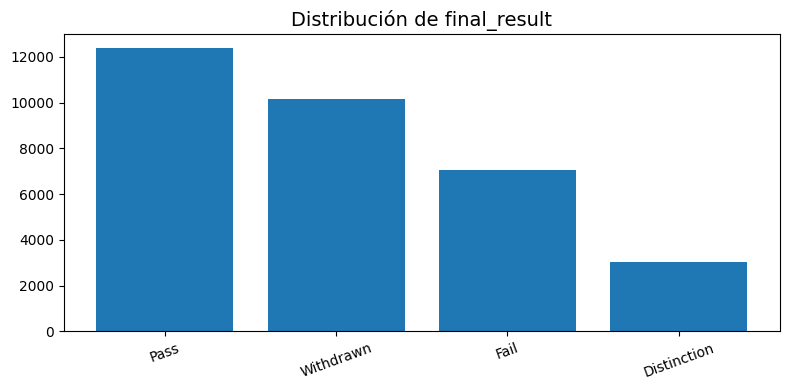

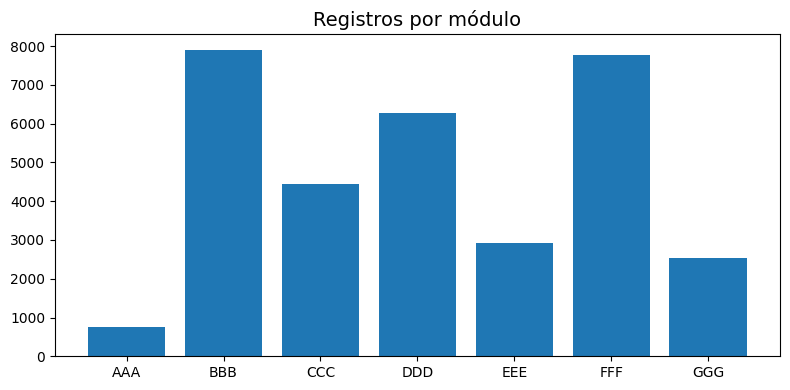

In [3]:
missing_df = pd.DataFrame({
    "columna": df.columns,
    "tipo": [str(df[c].dtype) for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns],
    "missing_%": [100*df[c].isna().mean() for c in df.columns],
}).sort_values("missing_%", ascending=False)
display(missing_df.head(18))

result_counts = df["final_result"].astype(str).value_counts()
display(result_counts.to_frame("frecuencia"))
plt.figure(figsize=(8,4)); plt.bar(result_counts.index, result_counts.values); plt.title("Distribución de final_result"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

module_counts = df["code_module"].astype(str).value_counts().sort_index()
plt.figure(figsize=(8,4)); plt.bar(module_counts.index, module_counts.values); plt.title("Registros por módulo"); plt.tight_layout(); plt.show()


# 6. Target y preparación

$$
\text{AtRisk}=1
\Longleftrightarrow
\text{final\_result}\in\{\text{Fail},\text{Withdrawn},\text{Withdrawal},\text{Dropout},\text{Absent}\}.
$$


In [4]:
def make_at_risk_target(series):
    adverse = {"Fail","Withdrawal","Withdrawn","Dropout","Absent","No Award"}
    return series.astype(str).str.strip().apply(lambda x: 1 if x in adverse else 0).astype(int)

work_df = df.copy()
work_df["at_risk"] = make_at_risk_target(work_df["final_result"])

if FAST_MODE and len(work_df) > MAX_ROWS_FAST:
    work_df = (work_df.groupby("at_risk", group_keys=False)
               .apply(lambda g: g.sample(min(len(g), max(100, int(MAX_ROWS_FAST*len(g)/len(df)))), random_state=SEED))
               .sample(frac=1, random_state=SEED).reset_index(drop=True))

model_df = work_df.drop(columns=["final_result","id_student"], errors="ignore")
high_cardinality_cols = [c for c in model_df.columns if c!="at_risk" and model_df[c].dtype=="object" and model_df[c].nunique(dropna=True)>60]
model_df = model_df.drop(columns=high_cardinality_cols, errors="ignore")

categorical_cols = [c for c in model_df.columns if c!="at_risk" and str(model_df[c].dtype) in {"object","category"}]
numeric_cols = [c for c in model_df.columns if c not in categorical_cols + ["at_risk"]]
X = model_df.drop(columns=["at_risk"])
y = model_df["at_risk"].astype(int)

print(f"Observaciones: {len(X):,}")
print(f"AtRisk=1: {y.mean():.2%}")
print("Categóricas:", len(categorical_cols), "Numéricas:", len(numeric_cols))
display(X.head())


Observaciones: 11,999
AtRisk=1: 52.80%
Categóricas: 8 Numéricas: 14


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,max_score,std_score,assessments_submitted,avg_submit_day,late_submit_rate,total_clicks,active_days,avg_clicks_per_day,max_clicks_day,std_clicks_day
0,EEE,2013J,M,North Region,Post Graduate Qualification,NaN,0-35,0,60,N,...,94.0,7.615773,4.0,95.00,0.500000,1144.0,67.0,4.468750,56.0,6.637313
1,CCC,2014J,M,London Region,A Level or Equivalent,80-90%,0-35,0,30,N,...,90.0,24.673873,5.0,132.80,0.600000,710.0,87.0,2.164634,52.0,3.550901
2,DDD,2013B,F,South West Region,A Level or Equivalent,50-60%,35-55,0,60,N,...,83.0,12.034748,14.0,119.00,0.428571,1058.0,82.0,2.618812,22.0,2.950080
3,BBB,2014J,F,North Western Region,A Level or Equivalent,30-40%,0-35,0,120,N,...,1.0,NaN,1.0,19.00,0.000000,121.0,11.0,2.086207,12.0,2.154428
4,CCC,2014B,M,South Region,HE Qualification,90-100%,0-35,0,30,N,...,100.0,13.266499,8.0,116.75,0.500000,539.0,50.0,2.961538,72.0,8.497231


# 7. Entrenamiento supervisado

Se entrenan modelos rápidos y controlados. La métrica principal es:

$$
F_1=2\frac{\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}.
$$


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, stratify=y if y.nunique()==2 else None, random_state=SEED)

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler(with_mean=False))])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_onehot_encoder())])
preprocessor = ColumnTransformer([("num", numeric_transformer, numeric_cols), ("cat", categorical_transformer, categorical_cols)], sparse_threshold=.3)

model_specs = {
    "Dummy_baseline": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=280 if FAST_MODE else 700, solver="liblinear", class_weight="balanced", random_state=SEED),
    "SGD_log_loss": SGDClassifier(loss="log_loss", max_iter=550 if FAST_MODE else 1200, early_stopping=True, n_iter_no_change=6, class_weight="balanced", random_state=SEED),
    "RandomForest_fast": RandomForestClassifier(n_estimators=60 if FAST_MODE else 160, max_depth=12 if FAST_MODE else 18, min_samples_leaf=8, n_jobs=-1, random_state=SEED, class_weight="balanced_subsample"),
    "ExtraTrees_fast": ExtraTreesClassifier(n_estimators=70 if FAST_MODE else 180, max_depth=12 if FAST_MODE else 18, min_samples_leaf=6, n_jobs=-1, random_state=SEED, class_weight="balanced")
}

if RUN_SLOW_MODELS:
    from sklearn.neural_network import MLPClassifier
    model_specs["MLP_optional_slow"] = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=120, early_stopping=True, random_state=SEED)

trained_models, results = {}, []
start_all = time.perf_counter()
for name, clf in model_specs.items():
    if time.perf_counter()-start_all > TRAINING_TIME_BUDGET_SECONDS:
        print("Presupuesto agotado. Se omite:", name); continue
    print("Entrenando:", name)
    t0=time.perf_counter()
    pipe = Pipeline([("preprocessor", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_score = model_probability(pipe, X_test)
    results.append({
        "model": name,
        "train_time_s": time.perf_counter()-t0,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": safe_auc(y_test, y_score)
    })
    trained_models[name]=pipe

results_df = pd.DataFrame(results).sort_values(["f1","roc_auc"], ascending=False).reset_index(drop=True)
display(results_df)
print(f"Tiempo total: {time.perf_counter()-start_all:.2f} s")


Entrenando: Dummy_baseline
Entrenando: LogisticRegression
Entrenando: SGD_log_loss
Entrenando: RandomForest_fast
Entrenando: ExtraTrees_fast


,model,train_time_s,accuracy,precision,recall,f1,roc_auc
0,RandomForest_fast,0.231964,0.933333,0.972033,0.899621,0.934426,0.980888
1,ExtraTrees_fast,0.148719,0.928667,0.967258,0.895202,0.929836,0.974227
2,LogisticRegression,0.091882,0.870667,0.895503,0.854798,0.874677,0.942459
3,SGD_log_loss,0.139416,0.858000,0.835458,0.910354,0.871299,0.939436
4,Dummy_baseline,0.045968,0.528000,0.528000,1.000000,0.691099,0.500000


Tiempo total: 0.71 s


# 8. Evaluación del mejor modelo

Se usan matriz de confusión, curva ROC y curva Precision-Recall para evitar conclusiones basadas solo en accuracy.


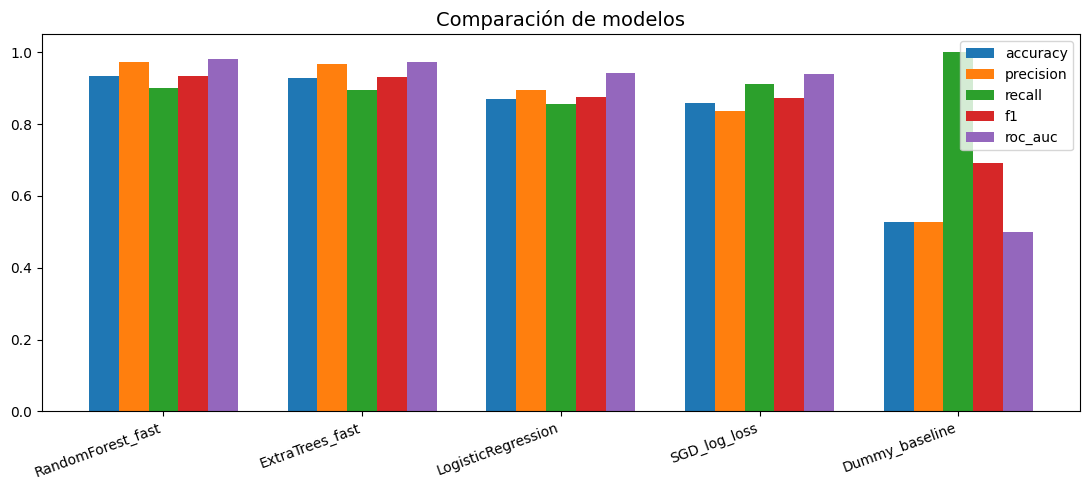

Mejor modelo: RandomForest_fast
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1416
           1       0.97      0.90      0.93      1584

    accuracy                           0.93      3000
   macro avg       0.93      0.94      0.93      3000
weighted avg       0.94      0.93      0.93      3000



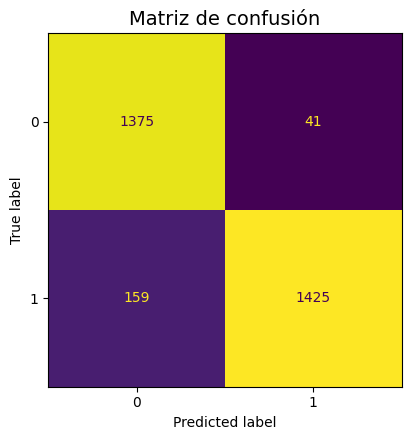

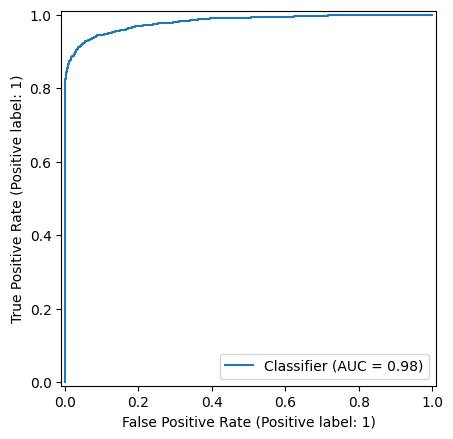

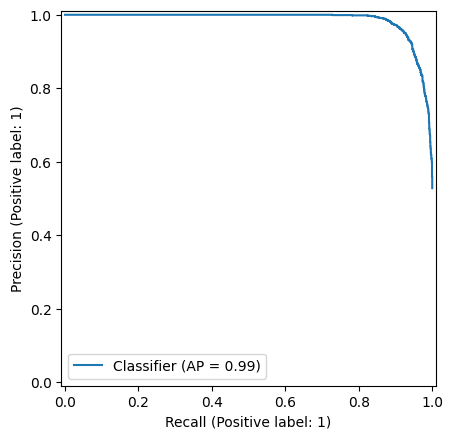

In [6]:
metric_names = ["accuracy","precision","recall","f1","roc_auc"]
plt.figure(figsize=(11,5))
x=np.arange(len(results_df)); width=.15
for i,m in enumerate(metric_names):
    plt.bar(x+i*width, results_df[m].fillna(0), width=width, label=m)
plt.xticks(x+width*2, results_df["model"], rotation=20, ha="right"); plt.ylim(0,1.05); plt.title("Comparación de modelos"); plt.legend(); plt.tight_layout(); plt.show()

best_model_name = results_df.iloc[0]["model"]
best_pipe = trained_models[best_model_name]
y_pred_best = best_pipe.predict(X_test)
y_score_best = model_probability(best_pipe, X_test)
print("Mejor modelo:", best_model_name)
print(classification_report(y_test, y_pred_best, zero_division=0))

fig,ax=plt.subplots(figsize=(5.5,4.5)); ConfusionMatrixDisplay.from_predictions(y_test,y_pred_best,ax=ax,colorbar=False); ax.set_title("Matriz de confusión"); plt.tight_layout(); plt.show()
if y_test.nunique()==2:
    fig,ax=plt.subplots(figsize=(6,4.5)); RocCurveDisplay.from_predictions(y_test,y_score_best,ax=ax); plt.tight_layout(); plt.show()
    fig,ax=plt.subplots(figsize=(6,4.5)); PrecisionRecallDisplay.from_predictions(y_test,y_score_best,ax=ax); plt.tight_layout(); plt.show()


# 9. Umbral de decisión por costo

En intervención académica un falso negativo puede ser más costoso:

$$
J(t)=c_{FN}FN(t)+c_{FP}FP(t).
$$


,valor
threshold,0.230000
fp,273.000000
fn,50.000000
cost,523.000000
precision,0.848921
recall,0.968434
f1,0.904748


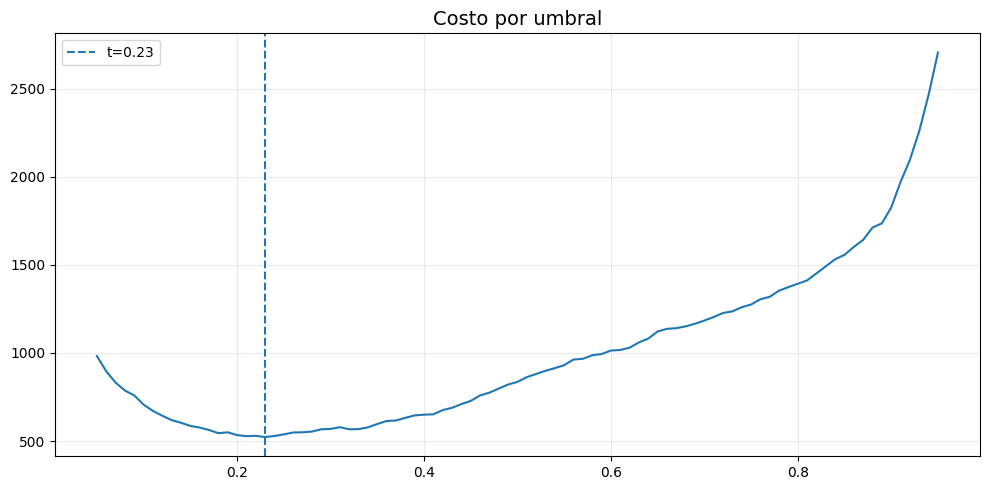

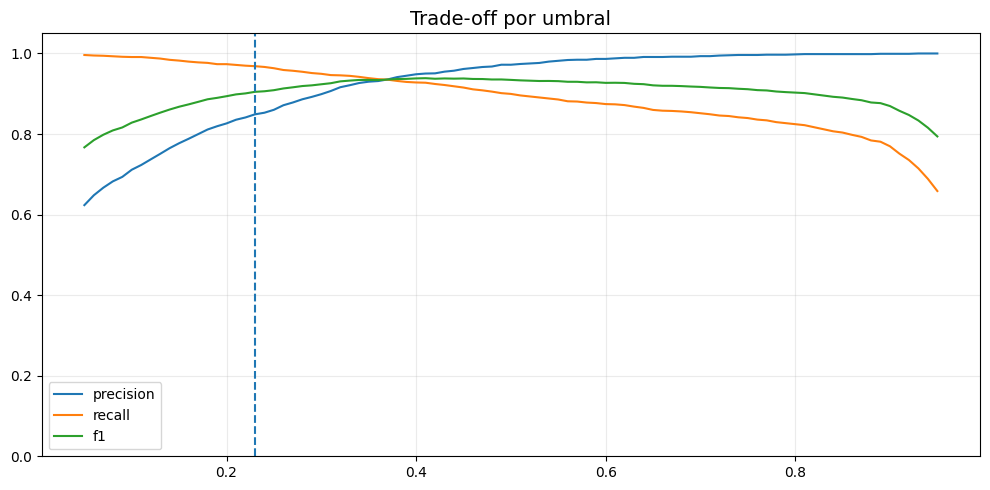

In [7]:
COST_FN, COST_FP = 5.0, 1.0
rows=[]
for t in np.linspace(.05,.95,91):
    pred=(y_score_best>=t).astype(int)
    fp=int(((pred==1)&(y_test.values==0)).sum())
    fn=int(((pred==0)&(y_test.values==1)).sum())
    rows.append({"threshold":t,"fp":fp,"fn":fn,"cost":COST_FN*fn+COST_FP*fp,
                 "precision":precision_score(y_test,pred,zero_division=0),
                 "recall":recall_score(y_test,pred,zero_division=0),
                 "f1":f1_score(y_test,pred,zero_division=0)})
threshold_df=pd.DataFrame(rows)
best_threshold_row=threshold_df.sort_values(["cost","f1"],ascending=[True,False]).iloc[0]
BEST_THRESHOLD=float(best_threshold_row["threshold"])
display(best_threshold_row.to_frame("valor"))

plt.figure(figsize=(10,5)); plt.plot(threshold_df["threshold"],threshold_df["cost"]); plt.axvline(BEST_THRESHOLD,linestyle="--",label=f"t={BEST_THRESHOLD:.2f}"); plt.title("Costo por umbral"); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,5)); 
for m in ["precision","recall","f1"]: plt.plot(threshold_df["threshold"],threshold_df[m],label=m)
plt.axvline(BEST_THRESHOLD,linestyle="--"); plt.ylim(0,1.05); plt.legend(); plt.title("Trade-off por umbral"); plt.grid(alpha=.25); plt.tight_layout(); plt.show()


# 10. Interpretabilidad rápida

La importancia por permutación se ejecuta en una muestra pequeña para explicar variables sin aumentar demasiado el tiempo.


,feature,importance_mean,importance_std
15,avg_submit_day,0.063642,0.008513
10,mean_score,0.015504,0.001265
12,max_score,0.013206,0.001704
11,min_score,0.012501,0.000883
16,late_submit_rate,0.011836,0.002920
0,code_module,0.006963,0.002529
17,total_clicks,0.006592,0.001353
14,assessments_submitted,0.006527,0.001439
18,active_days,0.004806,0.000548
13,std_score,0.004567,0.001354


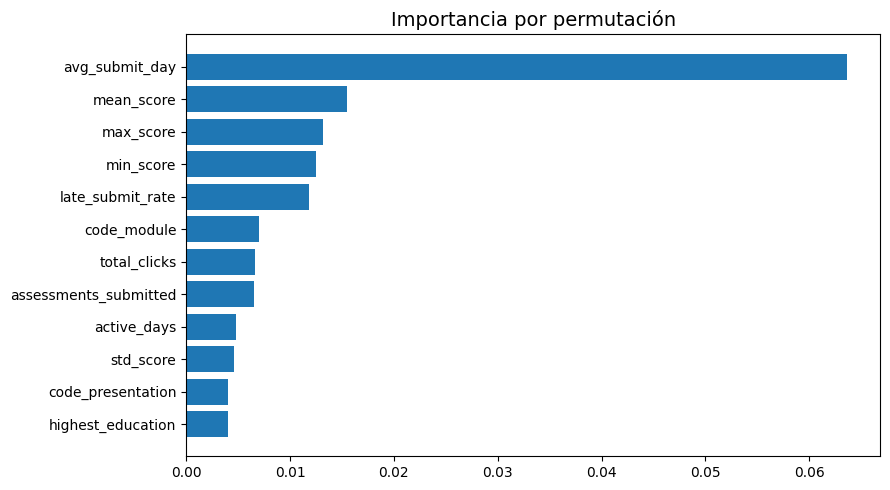

Tiempo: 5.38 s


In [8]:
sample_n=min(900 if FAST_MODE else 2500, len(X_test))
X_imp=X_test.sample(sample_n, random_state=SEED)
y_imp=y_test.loc[X_imp.index]
try:
    t0=time.perf_counter()
    perm=permutation_importance(best_pipe,X_imp,y_imp,n_repeats=3 if FAST_MODE else 8,random_state=SEED,scoring="f1",n_jobs=-1)
    imp_df=pd.DataFrame({"feature":X_imp.columns,"importance_mean":perm.importances_mean,"importance_std":perm.importances_std}).sort_values("importance_mean",ascending=False)
    display(imp_df.head(12))
    top=imp_df.head(12).sort_values("importance_mean")
    plt.figure(figsize=(9,5)); plt.barh(top["feature"],top["importance_mean"]); plt.title("Importancia por permutación"); plt.tight_layout(); plt.show()
    print(f"Tiempo: {time.perf_counter()-t0:.2f} s")
except Exception as e:
    print("No se pudo calcular importancia:", repr(e))


# 11. Demanda esperada

$$
\hat a_i=1-\hat p_i,\qquad
D_m=\sum_{i\in m}\hat a_i,\qquad
N_m=\left\lceil\frac{D_m}{\text{tamaño objetivo}}\right\rceil.
$$


,code_module,students,expected_active,mean_risk,scaled_expected_active,sections_needed
0,FFF,2838,1374.600156,0.515645,58,2
1,BBB,2918,1360.271827,0.533834,57,2
2,DDD,2322,991.927642,0.572813,42,2
3,CCC,1650,670.341618,0.593732,28,1
4,EEE,1074,587.057659,0.453391,25,1
5,GGG,921,545.192012,0.408043,23,1
6,AAA,276,185.493140,0.327923,12,1


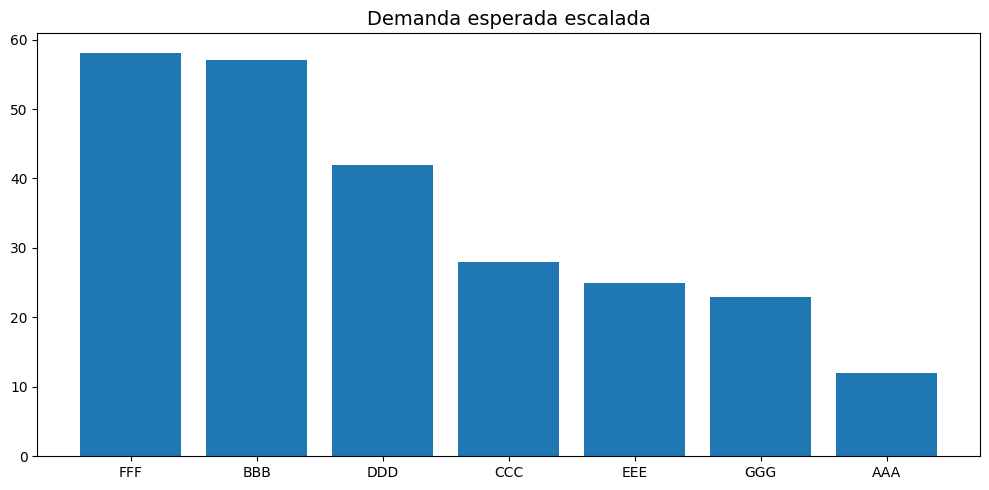

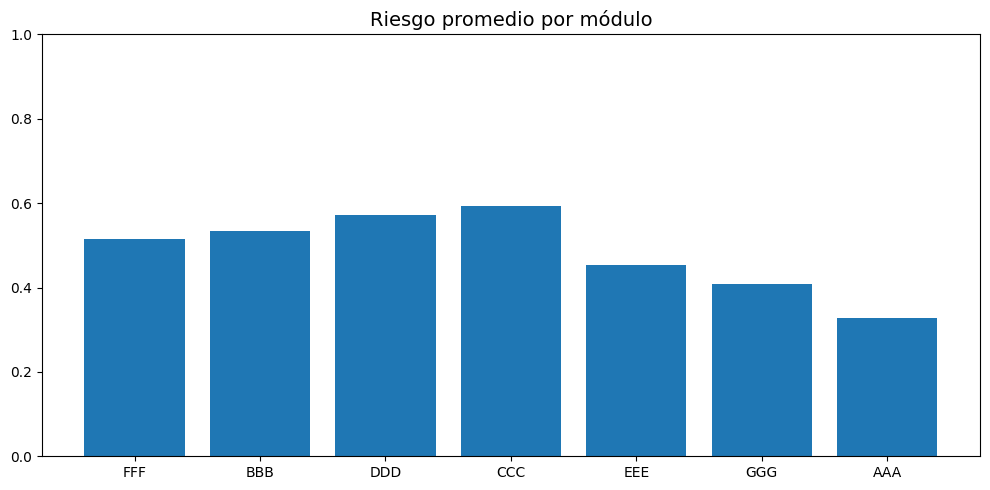

In [9]:
full_X = X.copy()
risk_proba = model_probability(best_pipe, full_X)
demand_df = work_df.loc[full_X.index].copy()
demand_df["risk_proba"] = risk_proba
demand_df["success_proba"] = 1-risk_proba

module_summary = demand_df.groupby("code_module").agg(
    students=("success_proba","size"),
    expected_active=("success_proba","sum"),
    mean_risk=("risk_proba","mean")
).reset_index()

PLANNING_TOTAL_STUDENTS = 240 if FAST_MODE else 700
TARGET_SECTION_SIZE = 30
MAX_SECTIONS_PER_MODULE = 4 if FAST_MODE else 7

total_expected=module_summary["expected_active"].sum()
module_summary["scaled_expected_active"]=np.maximum(12,np.round(module_summary["expected_active"]/total_expected*PLANNING_TOTAL_STUDENTS)).astype(int)
module_summary["sections_needed"]=np.ceil(module_summary["scaled_expected_active"]/TARGET_SECTION_SIZE).astype(int).clip(1,MAX_SECTIONS_PER_MODULE)
module_summary=module_summary.sort_values(["scaled_expected_active","mean_risk"],ascending=[False,True]).reset_index(drop=True)
display(module_summary)

plt.figure(figsize=(10,5)); plt.bar(module_summary["code_module"],module_summary["scaled_expected_active"]); plt.title("Demanda esperada escalada"); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,5)); plt.bar(module_summary["code_module"],module_summary["mean_risk"]); plt.title("Riesgo promedio por módulo"); plt.ylim(0,1); plt.tight_layout(); plt.show()


# 12. CSP de horarios

<p align="center"><img src="proyecto_final_mejorado_assets/02_csp_restricciones.png" width="860"/></p>


In [10]:
rooms=[
    {"room":"A-101","capacity":32,"type":"regular"},
    {"room":"A-102","capacity":36,"type":"regular"},
    {"room":"B-201","capacity":42,"type":"regular"},
    {"room":"B-202","capacity":48,"type":"regular"},
    {"room":"LAB-1","capacity":30,"type":"lab"},
    {"room":"LAB-2","capacity":34,"type":"lab"},
    {"room":"AUD-1","capacity":65,"type":"auditorium"},
]
days=["Lun","Mar","Mié","Jue","Vie"]; hours=["07:00","09:00","11:00","14:00","16:00"]
timeslots=[f"{d}-{h}" for d in days for h in hours]

top_modules=module_summary.head(7).copy()
module_list=top_modules["code_module"].tolist()
professors=[]
for i in range(8):
    mods=[module_list[(i+j)%len(module_list)] for j in range(min(4,len(module_list)))]
    professors.append({"name":f"Prof_{chr(65+i)}","modules":sorted(set(mods)),"prefers_morning":i%2==0})

sections=[]
for _,row in top_modules.iterrows():
    n=int(row["sections_needed"])
    per=int(math.ceil(row["scaled_expected_active"]/n))
    for k in range(n):
        sections.append({"section":f"{row['code_module']}-{k+1}","module":row["code_module"],"students":per,"module_mean_risk":row["mean_risk"]})
sections_df=pd.DataFrame(sections).head(22 if FAST_MODE else 45).reset_index(drop=True)
display(sections_df)
display(pd.DataFrame(professors))


,section,module,students,module_mean_risk
0,FFF-1,FFF,29,0.515645
1,FFF-2,FFF,29,0.515645
2,BBB-1,BBB,29,0.533834
3,BBB-2,BBB,29,0.533834
4,DDD-1,DDD,21,0.572813
5,DDD-2,DDD,21,0.572813
6,CCC-1,CCC,28,0.593732
7,EEE-1,EEE,25,0.453391
8,GGG-1,GGG,23,0.408043
9,AAA-1,AAA,12,0.327923


,name,modules,prefers_morning
0,Prof_A,"[BBB, CCC, DDD, FFF]",True
1,Prof_B,"[BBB, CCC, DDD, EEE]",False
2,Prof_C,"[CCC, DDD, EEE, GGG]",True
3,Prof_D,"[AAA, CCC, EEE, GGG]",False
4,Prof_E,"[AAA, EEE, FFF, GGG]",True
5,Prof_F,"[AAA, BBB, FFF, GGG]",False
6,Prof_G,"[AAA, BBB, DDD, FFF]",True
7,Prof_H,"[BBB, CCC, DDD, FFF]",False


In [11]:
TOP_K_DOMAIN=80 if FAST_MODE else 160
CSP_TIME_LIMIT_SECONDS=12 if FAST_MODE else 45
CSP_NODE_LIMIT=75000 if FAST_MODE else 300000
section_dict={row["section"]:row.to_dict() for _,row in sections_df.iterrows()}

def professor_candidates(module):
    return [p["name"] for p in professors if module in p["modules"]]
def is_morning(slot):
    return any(h in slot for h in ["07:00","09:00"])
def soft_score(section,value):
    slot,room,prof=value; row=section_dict[section]
    prof_info=next(p for p in professors if p["name"]==prof)
    room_info=next(r for r in rooms if r["room"]==room)
    score=0.0
    if prof_info["prefers_morning"] and is_morning(slot): score+=2.0
    if room_info["type"]=="auditorium" and row["students"]<38: score-=.8
    if room_info["type"]=="lab" and row["students"]<=room_info["capacity"]: score+=.4
    score += max(0,1.2-.03*(room_info["capacity"]-row["students"]))
    return score
def feasible_domain(section):
    row=section_dict[section]
    profs=professor_candidates(row["module"])
    feasible_rooms=[r["room"] for r in rooms if r["capacity"]>=row["students"]]
    raw=list(product(timeslots,feasible_rooms,profs))
    raw.sort(key=lambda v:-soft_score(section,v))
    return raw[:TOP_K_DOMAIN]
domains={sec:feasible_domain(sec) for sec in section_dict}
def consistent(section,value,assignment):
    slot,room,prof=value
    for other,oval in assignment.items():
        oslot,oroom,oprof=oval
        if slot==oslot and room==oroom: return False
        if slot==oslot and prof==oprof: return False
        if slot==oslot and section_dict[section]["module"]==section_dict[other]["module"]: return False
    return True
def compatible_values_count(section,assignment):
    return sum(1 for v in domains[section] if consistent(section,v,assignment))
def select_unassigned_variable(assignment):
    return min([s for s in domains if s not in assignment], key=lambda s:compatible_values_count(s,assignment))
def order_values(section,assignment):
    vals=[v for v in domains[section] if consistent(section,v,assignment)]
    vals.sort(key=lambda v:-soft_score(section,v))
    return vals

csp_stats={"nodes":0,"backtracks":0,"start":time.perf_counter()}
def backtracking_search(assignment):
    csp_stats["nodes"]+=1
    if len(assignment)==len(domains): return assignment.copy()
    if csp_stats["nodes"]>CSP_NODE_LIMIT or time.perf_counter()-csp_stats["start"]>CSP_TIME_LIMIT_SECONDS: return None
    section=select_unassigned_variable(assignment)
    for value in order_values(section,assignment):
        assignment[section]=value
        result=backtracking_search(assignment)
        if result is not None: return result
        assignment.pop(section,None); csp_stats["backtracks"]+=1
    return None

solution=backtracking_search({})
if solution is None:
    print("Respaldo greedy activado.")
    solution={}
    for section in sorted(domains,key=lambda s:len(domains[s])):
        for value in order_values(section,solution):
            if consistent(section,value,solution):
                solution[section]=value; break

print("Asignaciones:",len(solution),"de",len(domains))
print("Nodos:",csp_stats["nodes"],"Backtracks:",csp_stats["backtracks"],"Tiempo:",round(time.perf_counter()-csp_stats["start"],2),"s")
display(pd.Series({k:len(v) for k,v in domains.items()}).describe().to_frame("domain_size"))


Asignaciones: 10 de 10
Nodos: 11 Backtracks: 0 Tiempo: 0.0 s


,domain_size
count,10.0
mean,80.0
std,0.0
min,80.0
25%,80.0
50%,80.0
75%,80.0
max,80.0


# 13. Horario generado

<p align="center"><img src="proyecto_final_mejorado_assets/gif_02_csp_asignacion.gif" width="700"/></p>


,section,module,day,hour,slot,room,room_capacity,professor,students,occupancy,module_mean_risk
0,CCC-1,CCC,Jue,07:00,Jue-07:00,LAB-1,30,Prof_A,28,0.933333,0.593732
1,EEE-1,EEE,Jue,09:00,Jue-09:00,LAB-1,30,Prof_C,25,0.833333,0.453391
2,FFF-1,FFF,Lun,07:00,Lun-07:00,LAB-1,30,Prof_A,29,0.966667,0.515645
3,FFF-2,FFF,Lun,09:00,Lun-09:00,LAB-1,30,Prof_A,29,0.966667,0.515645
4,BBB-1,BBB,Mar,07:00,Mar-07:00,LAB-1,30,Prof_A,29,0.966667,0.533834
5,BBB-2,BBB,Mar,09:00,Mar-09:00,LAB-1,30,Prof_A,29,0.966667,0.533834
6,DDD-1,DDD,Mié,07:00,Mié-07:00,LAB-1,30,Prof_A,21,0.700000,0.572813
7,DDD-2,DDD,Mié,09:00,Mié-09:00,LAB-1,30,Prof_A,21,0.700000,0.572813
8,GGG-1,GGG,Vie,07:00,Vie-07:00,LAB-1,30,Prof_C,23,0.766667,0.408043
9,AAA-1,AAA,Vie,09:00,Vie-09:00,LAB-1,30,Prof_E,12,0.400000,0.327923


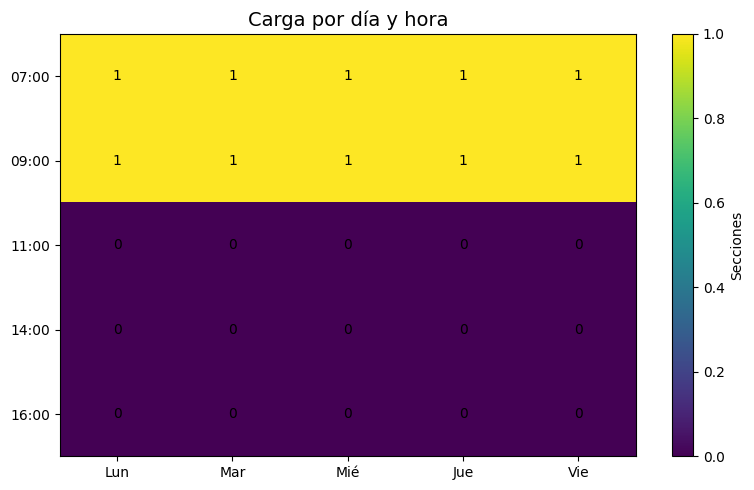

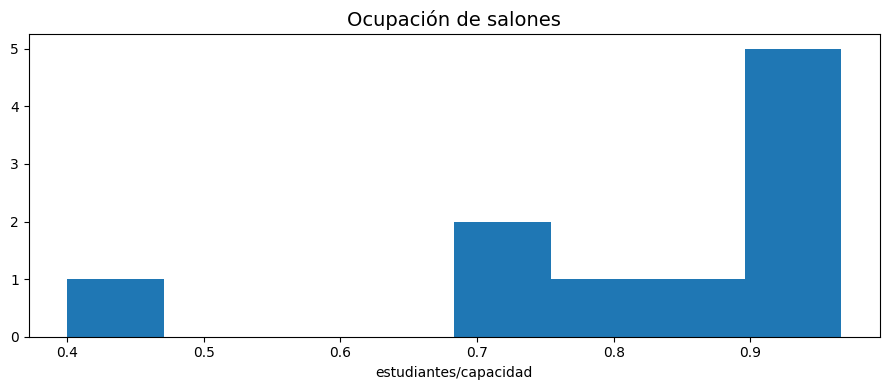

In [12]:
schedule_rows=[]
for sec,(slot,room,prof) in solution.items():
    module=section_dict[sec]["module"]
    students=section_dict[sec]["students"]
    room_capacity=next(r["capacity"] for r in rooms if r["room"]==room)
    day,hour=slot.split("-")
    schedule_rows.append({
        "section":sec,"module":module,"day":day,"hour":hour,"slot":slot,
        "room":room,"room_capacity":room_capacity,"professor":prof,"students":students,
        "occupancy":students/room_capacity,"module_mean_risk":section_dict[sec]["module_mean_risk"]
    })
schedule_df=pd.DataFrame(schedule_rows).sort_values(["day","hour","room"]).reset_index(drop=True)
display(schedule_df)

grid=pd.crosstab(schedule_df["hour"],schedule_df["day"]).reindex(index=hours,columns=days,fill_value=0)
plt.figure(figsize=(8,5)); plt.imshow(grid.values,aspect="auto"); plt.xticks(range(len(days)),days); plt.yticks(range(len(hours)),hours); plt.colorbar(label="Secciones"); plt.title("Carga por día y hora")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        plt.text(j,i,int(grid.values[i,j]),ha="center",va="center")
plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4)); plt.hist(schedule_df["occupancy"],bins=8); plt.title("Ocupación de salones"); plt.xlabel("estudiantes/capacidad"); plt.tight_layout(); plt.show()


# 14. Red Bayesiana — Estimación de Riesgo Operativo (Módulo 3)

La red bayesiana estima la probabilidad de que cada sección programada
requiera **replanificación**, dado el estado observable del horario.

### Estructura del grafo dirigido acíclico (DAG)

Nodos raíz (observables desde el horario):
- **Alta\_Demanda (AD)**: ocupación ≥ 0.70
- **Disp\_Docente (DD)**: presión docente < 0.65
- **Disp\_Aula (DA)**: ocupación < 0.88

Nodos latentes: **R\_Sobrecupo** y **R\_Cambio**

Nodo objetivo: **R\_Replanificación**

### Inferencia exacta por eliminación de variables

$$
P(\text{RR}=1 \mid \text{AD}, \text{DD}, \text{DA})
= \sum_{r_s}\sum_{r_c}
  P(\text{RS}=r_s\mid\text{AD})\;
  P(\text{RC}=r_c\mid\text{AD},\text{DD},\text{DA})\;
  P(\text{RR}=1\mid r_s,r_c)
$$

### Métricas de validación

- **Log-verosimilitud**: $\mathcal{L} = \sum_j \log P(e_j \mid \mathcal{B})$
- **Brier score**: $\text{BS} = \frac{1}{N}\sum_j (p_j - o_j)^2$

  CPT: P(R_Sobrecupo | Alta_Demanda)


,P(RS=0),P(RS=1)
Alta_Demanda,,
0,0.90,0.10
1,0.25,0.75



  CPT: P(R_Cambio | AD, Disp_Docente, Disp_Aula)


,AD,Disp_Doc,Disp_Aula,P(RC=0),P(RC=1)
0,0,0,0,0.10,0.90
1,0,0,1,0.25,0.75
2,0,1,0,0.30,0.70
3,0,1,1,0.85,0.15
4,1,0,0,0.05,0.95
5,1,0,1,0.12,0.88
6,1,1,0,0.18,0.82
7,1,1,1,0.42,0.58



  CPT: P(R_Replanif | R_Sobrecupo, R_Cambio)


,R_Sobrecupo,R_Cambio,P(RR=0),P(RR=1)
0,0,0,0.95,0.05
1,0,1,0.40,0.60
2,1,0,0.45,0.55
3,1,1,0.08,0.92



  Metricas de la Red Bayesiana
  Secciones evaluadas      : 10
  Log-verosimilitud total  : -27.1606
  Brier score              : 0.1170  (< 0.25 = aceptable)
  Riesgo medio P(Replanif) : 0.7188
  Secciones critico        : 7
  Secciones alto           : 2


,section,module,slot,room,professor,occupancy,teacher_pressure,bn_ad,bn_dd,bn_da,conflict_risk,risk_level
0,CCC-1,CCC,Jue-07:00,LAB-1,Prof_A,0.933333,1.000000,1,0,0,0.81925,critico
2,FFF-1,FFF,Lun-07:00,LAB-1,Prof_A,0.966667,1.000000,1,0,0,0.81925,critico
3,FFF-2,FFF,Lun-09:00,LAB-1,Prof_A,0.966667,1.000000,1,0,0,0.81925,critico
4,BBB-1,BBB,Mar-07:00,LAB-1,Prof_A,0.966667,1.000000,1,0,0,0.81925,critico
5,BBB-2,BBB,Mar-09:00,LAB-1,Prof_A,0.966667,1.000000,1,0,0,0.81925,critico
6,DDD-1,DDD,Mié-07:00,LAB-1,Prof_A,0.700000,1.000000,1,0,1,0.79020,critico
7,DDD-2,DDD,Mié-09:00,LAB-1,Prof_A,0.700000,1.000000,1,0,1,0.79020,critico
1,EEE-1,EEE,Jue-09:00,LAB-1,Prof_C,0.833333,0.285714,1,1,1,0.66570,alto
8,GGG-1,GGG,Vie-07:00,LAB-1,Prof_C,0.766667,0.285714,1,1,1,0.66570,alto
9,AAA-1,AAA,Vie-09:00,LAB-1,Prof_E,0.400000,0.142857,0,1,1,0.17980,bajo


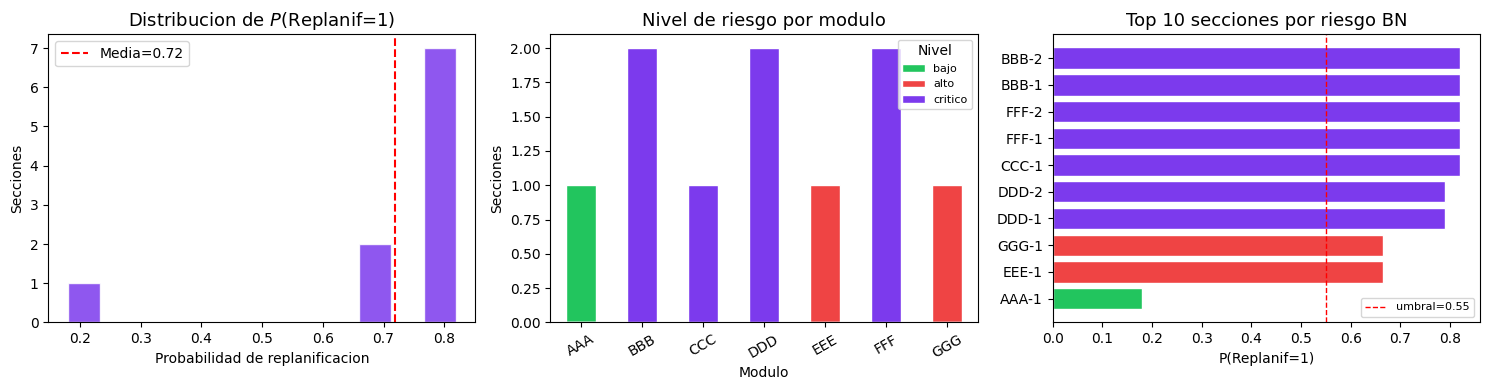


  P(Replanif=1) para las 8 combinaciones de evidencia:


,Alta_Demanda,Disp_Docente,Disp_Aula,P(Replanif=1),Nivel
0,0,0,0,0.5788,alto
1,0,0,1,0.4990,medio
2,0,1,0,0.4724,medio
3,0,1,1,0.1798,bajo
4,1,0,0,0.8192,critico
5,1,0,1,0.7902,critico
6,1,1,0,0.7653,critico
7,1,1,1,0.6657,alto


[BN] Modulo 3 completo — CPTs definidas, VE ejecutada, metricas calculadas.


In [13]:
# ===========================================================================
# 14. Red Bayesiana para estimacion de riesgo operativo
#     Modulo 3: razonamiento probabilistico con BN explicita
#     Implementacion manual — Variable Elimination (sin dependencia pgmpy)
# ===========================================================================
import itertools, math

# ── 14.1  Tablas de probabilidad condicional (CPT) ─────────────────────────

# Priors de nodos raiz
P_AD = {0: 0.35, 1: 0.65}   # P(Alta_Demanda)
P_DD = {0: 0.20, 1: 0.80}   # P(Disp_Docente)  1=disponible
P_DA = {0: 0.15, 1: 0.85}   # P(Disp_Aula)     1=disponible

# P(R_Sobrecupo=1 | Alta_Demanda)
CPT_RS = {
    0: {0: 0.90, 1: 0.10},
    1: {0: 0.25, 1: 0.75},
}

# P(R_Cambio=1 | AD, DD, DA)  — clave:(ad,dd,da), 1=disponible implica menor riesgo
CPT_RC = {
    (0,0,0): {0:0.10, 1:0.90},
    (0,0,1): {0:0.25, 1:0.75},
    (0,1,0): {0:0.30, 1:0.70},
    (0,1,1): {0:0.85, 1:0.15},
    (1,0,0): {0:0.05, 1:0.95},
    (1,0,1): {0:0.12, 1:0.88},
    (1,1,0): {0:0.18, 1:0.82},
    (1,1,1): {0:0.42, 1:0.58},
}

# P(R_Replanif=1 | RS, RC)
CPT_RR = {
    (0,0): {0:0.95, 1:0.05},
    (0,1): {0:0.40, 1:0.60},
    (1,0): {0:0.45, 1:0.55},
    (1,1): {0:0.08, 1:0.92},
}

# ── 14.2  Inferencia exacta por eliminacion de variables ───────────────────

def bn_infer_replanif(ad, dd, da):
    """P(R_Replanif=1 | AD=ad, DD=dd, DA=da) — VE sobre RS y RC."""
    p = 0.0
    for rs in (0,1):
        for rc in (0,1):
            p += CPT_RS[ad][rs] * CPT_RC[(ad,dd,da)][rc] * CPT_RR[(rs,rc)][1]
    return p

def bn_log_evidence(ad, dd, da):
    """log P(AD=ad, DD=dd, DA=da) — log-verosimilitud de la evidencia."""
    p_ev = 0.0
    for rs in (0,1):
        for rc in (0,1):
            for rr in (0,1):
                p_ev += (P_AD[ad]*P_DD[dd]*P_DA[da]
                         *CPT_RS[ad][rs]
                         *CPT_RC[(ad,dd,da)][rc]
                         *CPT_RR[(rs,rc)][rr])
    return math.log(p_ev + 1e-12)

# ── 14.3  Mostrar CPTs ─────────────────────────────────────────────────────

print('=' * 58)
print('  CPT: P(R_Sobrecupo | Alta_Demanda)')
print('=' * 58)
cpt_rs_df = pd.DataFrame({'Alta_Demanda':[0,1],
    'P(RS=0)':[CPT_RS[0][0],CPT_RS[1][0]],
    'P(RS=1)':[CPT_RS[0][1],CPT_RS[1][1]]})
display(cpt_rs_df.set_index('Alta_Demanda'))

print('\n' + '=' * 58)
print('  CPT: P(R_Cambio | AD, Disp_Docente, Disp_Aula)')
print('=' * 58)
rows_rc = [{'AD':k[0],'Disp_Doc':k[1],'Disp_Aula':k[2],
            'P(RC=0)':round(v[0],2),'P(RC=1)':round(v[1],2)}
           for k,v in CPT_RC.items()]
display(pd.DataFrame(rows_rc))

print('\n' + '=' * 58)
print('  CPT: P(R_Replanif | R_Sobrecupo, R_Cambio)')
print('=' * 58)
rows_rr = [{'R_Sobrecupo':k[0],'R_Cambio':k[1],
            'P(RR=0)':round(v[0],2),'P(RR=1)':round(v[1],2)}
           for k,v in CPT_RR.items()]
display(pd.DataFrame(rows_rr))

# ── 14.4  Derivar evidencia del horario y ejecutar inferencia ──────────────

risk_df = schedule_df.copy()
teacher_load = risk_df['professor'].value_counts()
slot_density  = risk_df['slot'].value_counts()

risk_df['teacher_pressure'] = (risk_df['professor'].map(teacher_load)
                                / max(1, teacher_load.max()))
risk_df['slot_density']     = (risk_df['slot'].map(slot_density)
                                / max(1, len(rooms)))

OCC_DEMAND_THR    = 0.70
TEACHER_AVAIL_THR = 0.65
ROOM_AVAIL_THR    = 0.88

risk_df['bn_ad'] = (risk_df['occupancy']        >= OCC_DEMAND_THR).astype(int)
risk_df['bn_dd'] = (risk_df['teacher_pressure'] <  TEACHER_AVAIL_THR).astype(int)
risk_df['bn_da'] = (risk_df['occupancy']        <  ROOM_AVAIL_THR).astype(int)

risk_df['conflict_risk'] = risk_df.apply(
    lambda r: bn_infer_replanif(int(r['bn_ad']), int(r['bn_dd']), int(r['bn_da'])),
    axis=1
)
risk_df['log_lik_section'] = risk_df.apply(
    lambda r: bn_log_evidence(int(r['bn_ad']), int(r['bn_dd']), int(r['bn_da'])),
    axis=1
)
risk_df['risk_level'] = pd.cut(
    risk_df['conflict_risk'],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.0],
    labels=['bajo','medio','alto','critico']
)

# ── 14.5  Metricas de validacion de la red bayesiana ───────────────────────

total_log_lik = risk_df['log_lik_section'].sum()
risk_df['empirical_label'] = (
    (risk_df['occupancy'] >= 0.85) | (risk_df['teacher_pressure'] >= 0.70)
).astype(float)
brier_score = ((risk_df['conflict_risk'] - risk_df['empirical_label'])**2).mean()

print('\n' + '='*58)
print('  Metricas de la Red Bayesiana')
print('='*58)
print(f'  Secciones evaluadas      : {len(risk_df)}')
print(f'  Log-verosimilitud total  : {total_log_lik:.4f}')
print(f'  Brier score              : {brier_score:.4f}  (< 0.25 = aceptable)')
print(f'  Riesgo medio P(Replanif) : {risk_df["conflict_risk"].mean():.4f}')
print(f'  Secciones critico        : {(risk_df["risk_level"]=="critico").sum()}')
print(f'  Secciones alto           : {(risk_df["risk_level"]=="alto").sum()}')
print('='*58)

bn_metrics = {
    'log_likelihood' : round(total_log_lik, 4),
    'brier_score'    : round(brier_score, 4),
    'mean_risk'      : round(risk_df['conflict_risk'].mean(), 4),
    'n_critico'      : int((risk_df['risk_level']=='critico').sum()),
    'n_alto'         : int((risk_df['risk_level']=='alto').sum()),
    'n_sections'     : len(risk_df),
}

# ── 14.6  Tabla top riesgo ─────────────────────────────────────────────────

view_cols = ['section','module','slot','room','professor',
             'occupancy','teacher_pressure','bn_ad','bn_dd','bn_da',
             'conflict_risk','risk_level']
display(risk_df.sort_values('conflict_risk',ascending=False)[view_cols].head(12))

# ── 14.7  Graficos ─────────────────────────────────────────────────────────

import os
os.makedirs('output_latex', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(risk_df['conflict_risk'], bins=12,
             color='#7c3aed', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribucion de $P$(Replanif=1)', fontsize=13)
axes[0].set_xlabel('Probabilidad de replanificacion')
axes[0].set_ylabel('Secciones')
axes[0].axvline(risk_df['conflict_risk'].mean(), color='red', linestyle='--',
                label=f"Media={risk_df['conflict_risk'].mean():.2f}")
axes[0].legend()

level_colors = {'bajo':'#22c55e','medio':'#f59e0b','alto':'#ef4444','critico':'#7c3aed'}
risk_by_mod = (risk_df.groupby(['module','risk_level'], observed=True)
               .size().unstack(fill_value=0))
risk_by_mod.plot(kind='bar', stacked=True,
    color=[level_colors.get(c,'#888') for c in risk_by_mod.columns],
    ax=axes[1], edgecolor='white')
axes[1].set_title('Nivel de riesgo por modulo', fontsize=13)
axes[1].set_xlabel('Modulo'); axes[1].set_ylabel('Secciones')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Nivel', fontsize=8)

top10 = risk_df.sort_values('conflict_risk', ascending=False).head(10).sort_values('conflict_risk')
bar_colors = [level_colors.get(str(lv),'#888') for lv in top10['risk_level']]
axes[2].barh(top10['section'], top10['conflict_risk'], color=bar_colors, edgecolor='white')
axes[2].set_title('Top 10 secciones por riesgo BN', fontsize=13)
axes[2].set_xlabel('P(Replanif=1)')
axes[2].axvline(0.55, color='red', linestyle='--', linewidth=1, label='umbral=0.55')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('output_latex/fig_14_bn_riesgo.pdf', dpi=150, bbox_inches='tight')
plt.show()

# ── 14.8  Tabla de probabilidades inferidas para las 8 configuraciones ─────

print('\n  P(Replanif=1) para las 8 combinaciones de evidencia:')
inf_rows = []
for ad,dd,da in itertools.product([0,1],[0,1],[0,1]):
    p = bn_infer_replanif(ad, dd, da)
    inf_rows.append({'Alta_Demanda':ad,'Disp_Docente':dd,'Disp_Aula':da,
                     'P(Replanif=1)':round(p,4),
                     'Nivel':'critico' if p>=0.75 else 'alto' if p>=0.50
                            else 'medio' if p>=0.25 else 'bajo'})
inference_table = pd.DataFrame(inf_rows)
display(inference_table)

print('[BN] Modulo 3 completo — CPTs definidas, VE ejecutada, metricas calculadas.')

# 15. MDP para replanificación

<p align="center"><img src="proyecto_final_mejorado_assets/03_mdp_estados.png" width="850"/></p>


,state,V(s),policy
0,normal,139.999992,open_extra
1,high_demand,160.487796,open_extra
2,room_issue,165.934057,move_room
3,teacher_issue,163.736255,move_slot
4,high_risk,161.339016,open_extra
5,resolved,179.999992,notify_coordination


,keep,move_room,move_slot,open_extra,notify_coordination
normal,133.16,139.00,139.00,140.00,136.00
high_demand,143.41,152.99,149.04,160.49,155.83
room_issue,143.78,165.93,154.80,156.12,156.74
teacher_issue,143.25,145.55,163.74,150.10,159.71
high_risk,136.46,157.80,157.49,161.34,160.30
resolved,179.50,179.00,178.00,175.00,180.00


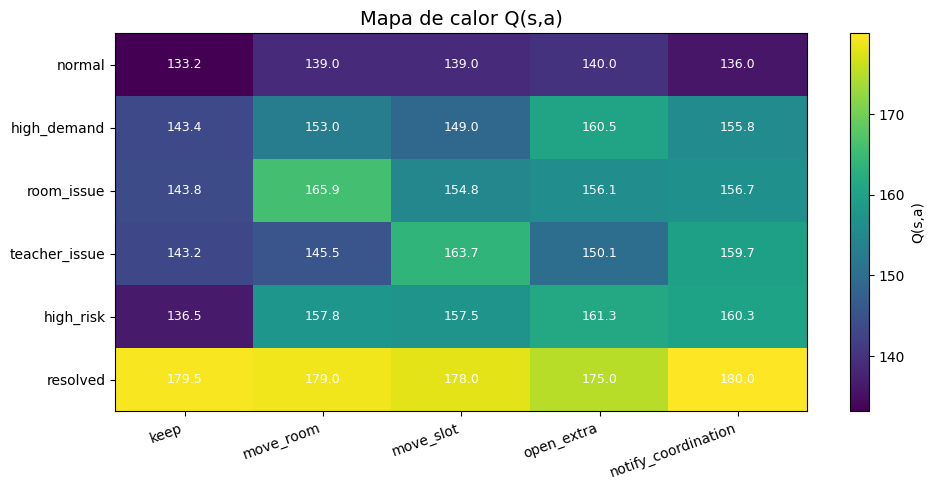

In [14]:
states=["normal","high_demand","room_issue","teacher_issue","high_risk","resolved"]
actions=["keep","move_room","move_slot","open_extra","notify_coordination"]
gamma=.90
T={
"normal":{"keep":{"normal":.82,"high_demand":.06,"room_issue":.04,"teacher_issue":.04,"high_risk":.04},"move_room":{"normal":.80,"resolved":.20},"move_slot":{"normal":.78,"resolved":.22},"open_extra":{"normal":.70,"resolved":.30},"notify_coordination":{"normal":.88,"resolved":.12}},
"high_demand":{"keep":{"high_demand":.62,"high_risk":.25,"resolved":.13},"move_room":{"high_demand":.42,"resolved":.38,"room_issue":.20},"move_slot":{"high_demand":.48,"resolved":.32,"teacher_issue":.20},"open_extra":{"resolved":.68,"high_demand":.20,"normal":.12},"notify_coordination":{"high_demand":.38,"resolved":.46,"normal":.16}},
"room_issue":{"keep":{"room_issue":.70,"high_risk":.20,"resolved":.10},"move_room":{"resolved":.72,"normal":.18,"room_issue":.10},"move_slot":{"resolved":.48,"normal":.22,"room_issue":.30},"open_extra":{"resolved":.60,"normal":.25,"high_demand":.15},"notify_coordination":{"room_issue":.40,"resolved":.46,"normal":.14}},
"teacher_issue":{"keep":{"teacher_issue":.68,"high_risk":.20,"resolved":.12},"move_room":{"teacher_issue":.55,"resolved":.25,"normal":.20},"move_slot":{"resolved":.70,"normal":.20,"teacher_issue":.10},"open_extra":{"resolved":.45,"high_demand":.35,"normal":.20},"notify_coordination":{"resolved":.55,"teacher_issue":.30,"normal":.15}},
"high_risk":{"keep":{"high_risk":.78,"room_issue":.10,"teacher_issue":.08,"resolved":.04},"move_room":{"resolved":.52,"normal":.18,"room_issue":.30},"move_slot":{"resolved":.55,"normal":.18,"teacher_issue":.27},"open_extra":{"resolved":.70,"high_demand":.18,"normal":.12},"notify_coordination":{"resolved":.60,"high_risk":.25,"normal":.15}},
"resolved":{"keep":{"resolved":.95,"normal":.05},"move_room":{"resolved":1.0},"move_slot":{"resolved":1.0},"open_extra":{"resolved":1.0},"notify_coordination":{"resolved":1.0}}
}
def reward(s,a,sp):
    base=0
    if sp=="resolved": base+=20
    if sp=="normal": base+=6
    if sp=="high_risk": base-=12
    if sp in {"room_issue","teacher_issue"}: base-=8
    if sp=="high_demand": base-=5
    return base + {"keep":0,"move_room":-3,"move_slot":-4,"open_extra":-7,"notify_coordination":-2}[a]
def value_iteration(states,actions,T,gamma=.9,theta=1e-6,max_iter=200):
    V={s:0.0 for s in states}
    history=[]
    for _ in range(max_iter):
        delta=0; newV={}
        for s in states:
            qs=[sum(prob*(reward(s,a,sp)+gamma*V[sp]) for sp,prob in T[s][a].items()) for a in actions]
            newV[s]=max(qs); delta=max(delta,abs(newV[s]-V[s]))
        V=newV; history.append(V.copy())
        if delta<theta: break
    Q=pd.DataFrame(index=states,columns=actions,dtype=float); policy={}
    for s in states:
        for a in actions:
            Q.loc[s,a]=sum(prob*(reward(s,a,sp)+gamma*V[sp]) for sp,prob in T[s][a].items())
        policy[s]=Q.loc[s].astype(float).idxmax()
    return V,policy,Q,history
V,policy,Q_table,vi_history=value_iteration(states,actions,T,gamma)
display(pd.DataFrame({"state":states,"V(s)":[V[s] for s in states],"policy":[policy[s] for s in states]}))
display(Q_table.round(2))

plt.figure(figsize=(10,5)); plt.imshow(Q_table.values.astype(float),aspect="auto"); plt.xticks(range(len(actions)),actions,rotation=20,ha="right"); plt.yticks(range(len(states)),states); plt.colorbar(label="Q(s,a)"); plt.title("Mapa de calor Q(s,a)")
for i in range(len(states)):
    for j in range(len(actions)):
        plt.text(j,i,f"{Q_table.iloc[i,j]:.1f}",ha="center",va="center",color="white",fontsize=9)
plt.tight_layout(); plt.show()


<p align="center"><img src="proyecto_final_mejorado_assets/gif_03_value_iteration.gif" width="730"/></p>


# 16. Recomendación automática

$$
\text{estado}(s_j)=
\begin{cases}
\text{high\_risk}, & r_j\geq 0.55\\
\text{room\_issue}, & \text{ocupación}_j\geq 0.90\\
\text{teacher\_issue}, & \text{cargaProfesor}_j\geq 0.75\\
\text{normal}, & \text{en otro caso}
\end{cases}
$$


,section,module,slot,room,professor,students,occupancy,teacher_pressure,slot_density,conflict_risk,mdp_state,recommended_action
0,CCC-1,CCC,Jue-07:00,LAB-1,Prof_A,28,0.933333,1.000000,0.142857,0.81925,high_risk,open_extra
2,FFF-1,FFF,Lun-07:00,LAB-1,Prof_A,29,0.966667,1.000000,0.142857,0.81925,high_risk,open_extra
3,FFF-2,FFF,Lun-09:00,LAB-1,Prof_A,29,0.966667,1.000000,0.142857,0.81925,high_risk,open_extra
4,BBB-1,BBB,Mar-07:00,LAB-1,Prof_A,29,0.966667,1.000000,0.142857,0.81925,high_risk,open_extra
5,BBB-2,BBB,Mar-09:00,LAB-1,Prof_A,29,0.966667,1.000000,0.142857,0.81925,high_risk,open_extra
6,DDD-1,DDD,Mié-07:00,LAB-1,Prof_A,21,0.700000,1.000000,0.142857,0.79020,high_risk,open_extra
7,DDD-2,DDD,Mié-09:00,LAB-1,Prof_A,21,0.700000,1.000000,0.142857,0.79020,high_risk,open_extra
1,EEE-1,EEE,Jue-09:00,LAB-1,Prof_C,25,0.833333,0.285714,0.142857,0.66570,high_risk,open_extra
8,GGG-1,GGG,Vie-07:00,LAB-1,Prof_C,23,0.766667,0.285714,0.142857,0.66570,high_risk,open_extra
9,AAA-1,AAA,Vie-09:00,LAB-1,Prof_E,12,0.400000,0.142857,0.142857,0.17980,normal,open_extra


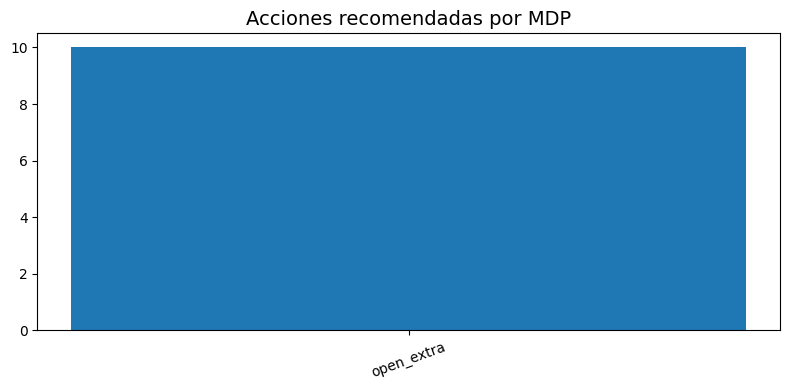

In [15]:
def infer_mdp_state(row):
    if row["conflict_risk"]>=.55: return "high_risk"
    if row["occupancy"]>=.90: return "room_issue"
    if row["teacher_pressure"]>=.75: return "teacher_issue"
    return "normal"

recommendations=risk_df.copy()
recommendations["mdp_state"]=recommendations.apply(infer_mdp_state,axis=1)
recommendations["recommended_action"]=recommendations["mdp_state"].map(policy)
view_cols=["section","module","slot","room","professor","students","occupancy","teacher_pressure","slot_density","conflict_risk","mdp_state","recommended_action"]
display(recommendations.sort_values("conflict_risk",ascending=False)[view_cols].head(15))

action_counts=recommendations["recommended_action"].value_counts()
plt.figure(figsize=(8,4)); plt.bar(action_counts.index,action_counts.values); plt.title("Acciones recomendadas por MDP"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()


# 17. Dashboard final


,Indicador,Valor
0,Modo de datos,OULAD real
1,Observaciones usadas,"11,999"
2,Mejor modelo,RandomForest_fast
3,Tiempo modelos (s),0.66
4,F1,0.934
5,AUC,0.981
6,Umbral recomendado,0.23
7,Módulos planificados,7
8,Secciones programadas,10
9,Backtracks CSP,0


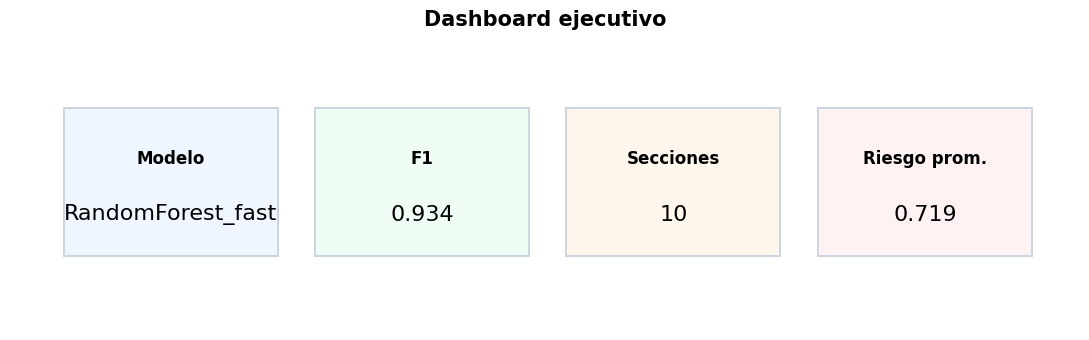

In [16]:
best_row=results_df.iloc[0]
summary=pd.DataFrame({
    "Indicador":["Modo de datos","Observaciones usadas","Mejor modelo","Tiempo modelos (s)","F1","AUC","Umbral recomendado","Módulos planificados","Secciones programadas","Backtracks CSP","Riesgo promedio","Secciones riesgo >= 0.55","Acción MDP más frecuente"],
    "Valor":[DATA_MODE,f"{len(X):,}",best_row["model"],f"{results_df['train_time_s'].sum():.2f}",f"{best_row['f1']:.3f}",f"{best_row['roc_auc']:.3f}" if not pd.isna(best_row["roc_auc"]) else "N/A",f"{BEST_THRESHOLD:.2f}",str(len(top_modules)),str(len(schedule_df)),str(csp_stats["backtracks"]),f"{risk_df['conflict_risk'].mean():.3f}",str((risk_df["conflict_risk"]>=.55).sum()),action_counts.index[0] if len(action_counts) else "N/A"]
})
display(summary)

fig,ax=plt.subplots(figsize=(11,3.5)); ax.axis("off")
cards=[("Modelo",best_row["model"],"#eff6ff"),("F1",f"{best_row['f1']:.3f}","#f0fdf4"),("Secciones",str(len(schedule_df)),"#fff7ed"),("Riesgo prom.",f"{risk_df['conflict_risk'].mean():.3f}","#fef2f2")]
for i,(title,value,color) in enumerate(cards):
    x=.05+i*.235
    ax.add_patch(plt.Rectangle((x,.25),.20,.50,transform=ax.transAxes,facecolor=color,edgecolor="#cbd5e1",linewidth=1.4))
    ax.text(x+.10,.58,title,transform=ax.transAxes,ha="center",va="center",fontsize=12,fontweight="bold")
    ax.text(x+.10,.39,value,transform=ax.transAxes,ha="center",va="center",fontsize=16)
plt.title("Dashboard ejecutivo",fontsize=15,fontweight="bold"); plt.tight_layout(); plt.show()


# 18. Validación conceptual

| Componente | Técnica de IA | Papel |
|---|---|---|
| Predicción de riesgo | Aprendizaje supervisado | Estimar $P(y=1\mid x)$ |
| Horarios | CSP / búsqueda heurística | Encontrar asignaciones factibles |
| Riesgo operativo | Razonamiento probabilístico | Modelar incertidumbre |
| Replanificación | MDP / value iteration | Elegir acciones bajo consecuencias futuras |

## Limitaciones

- Si se usa dataset sintético, los resultados son demostrativos.
- OULAD no trae salones ni docentes reales; esa parte se simula.
- El riesgo operativo es explicativo, no causal.
- Las transiciones del MDP fueron diseñadas manualmente.

## Trabajo futuro

- Agregar disponibilidad docente real.
- Calibrar probabilidades temporalmente.
- Usar CP-SAT para instancias grandes.
- Aprender $T(s,a,s')$ con datos históricos.


# 19. Bitácora de IA generativa

| Prompt | Uso | Validación |
|---|---|---|
| “Mejora un notebook de IA híbrida con aprendizaje supervisado, CSP, riesgo probabilístico y MDP.” | Estructura del proyecto. | Se verificó que cada módulo corresponda a un tema de IA y que alimente al siguiente. |
| “Optimiza el entrenamiento para que no tarde una hora.” | Selección de modelos rápidos. | Se limitaron iteraciones, árboles, tamaño de muestra y se desactivó MLP por defecto. |
| “Incluye MathJax y visuales relevantes.” | Documentación matemática y gráficos. | Se revisaron ecuaciones de regresión logística, CSP, costo por umbral y value iteration. |


# 20. Referencias egráficas

- Open University Learning Analytics Dataset (OULAD):  
  https://analyse.kmi.open.ac.uk/open_dataset

- UCI Machine Learning Repository — Open University Learning Analytics Dataset:  
  https://archive.ics.uci.edu/dataset/349/open+university+learning+analytics+dataset

- Scikit-learn — User Guide:  
  https://scikit-learn.org/stable/user_guide.html

- Scikit-learn — Model evaluation:  
  https://scikit-learn.org/stable/modules/model_evaluation.html

- AIMA — Artificial Intelligence: A Modern Approach:  
  https://aima.cs.berkeley.edu/

- Sutton, R. S. & Barto, A. G. *Reinforcement Learning: An Introduction*:  
  http://incompleteideas.net/book/the-book-2nd.html

- Stanford Encyclopedia of Philosophy — Logic and Artificial Intelligence:  
  https://plato.stanford.edu/entries/logic-ai/


# 21. Conclusión

<div class="good-card">
El proyecto integra aprendizaje automático, CSP, razonamiento probabilístico y MDP en una misma cadena de decisión. El aprendizaje responde “¿qué puede pasar?”, el CSP responde “¿qué asignaciones son factibles?”, el módulo probabilístico responde “¿qué tan riesgoso es?” y el MDP responde “¿qué acción conviene tomar?”.
</div>


# 22. Exportación de resultados para LaTeX

Este bloque recopila **todas las tablas, gráficos y valores numéricos** producidos
por el notebook y los guarda en la carpeta `output_latex/`.

El archivo `main.tex` puede incluirlos directamente con:
```latex
\includegraphics{output_latex/fig_14_bn_riesgo.pdf}
\input{output_latex/tabla_ml_modelos.tex}
```

In [18]:
# ===========================================================================
# 22. EXPORTACION DE RESULTADOS PARA LATEX
#     Guarda en output_latex/ todos los artefactos que LaTeX necesita:
#     figuras (.pdf), tablas (.csv + .tex) y metricas (.json)
# ===========================================================================
import os, json as _json
from pathlib import Path

OUT = Path('output_latex')
OUT.mkdir(exist_ok=True)
print(f'Exportando a: {OUT.resolve()}')

# ── 22.1  Figuras — Aprendizaje supervisado ─────────────────────────────

# Confusion matrix
fig_cm, ax_cm = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_estimator(
    best_pipe, X_test, y_test, ax=ax_cm,
    display_labels=['No riesgo','En riesgo'], cmap='Blues')
ax_cm.set_title(f'Matriz de confusion ({best_row["model"]})')
fig_cm.tight_layout()
fig_cm.savefig(OUT / 'fig_cm.pdf', dpi=150, bbox_inches='tight')
plt.close(fig_cm)
print('  [OK] fig_cm.pdf')

# ROC curve
fig_roc, ax_roc = plt.subplots(figsize=(5,4))
RocCurveDisplay.from_estimator(best_pipe, X_test, y_test, ax=ax_roc)
ax_roc.set_title('Curva ROC')
fig_roc.tight_layout()
fig_roc.savefig(OUT / 'fig_roc.pdf', dpi=150, bbox_inches='tight')
plt.close(fig_roc)
print('  [OK] fig_roc.pdf')

# PR curve
fig_pr, ax_pr = plt.subplots(figsize=(5,4))
PrecisionRecallDisplay.from_estimator(best_pipe, X_test, y_test, ax=ax_pr)
ax_pr.set_title('Curva Precision-Recall')
fig_pr.tight_layout()
fig_pr.savefig(OUT / 'fig_pr.pdf', dpi=150, bbox_inches='tight')
plt.close(fig_pr)
print('  [OK] fig_pr.pdf')

# Comparacion de modelos — barras
fig_mod, ax_mod = plt.subplots(figsize=(8,4))
_rf = results_df.sort_values('f1', ascending=True)
ax_mod.barh(_rf['model'], _rf['f1'], color='#3b82f6', edgecolor='white')
ax_mod.set_xlabel('F1-score')
ax_mod.set_title('Comparacion de modelos ML')
ax_mod.axvline(_rf['f1'].max(), linestyle='--', color='red', linewidth=1)
fig_mod.tight_layout()
fig_mod.savefig(OUT / 'fig_ml_modelos.pdf', dpi=150, bbox_inches='tight')
plt.close(fig_mod)
print('  [OK] fig_ml_modelos.pdf')

# Importancia de variables
if 'imp_df' in dir():
    fig_imp, ax_imp = plt.subplots(figsize=(7,4))
    _top_imp = imp_df.head(12)
    #ax_imp.barh(_top_imp['feature'], _top_imp['importance'], color='#10b981')
    ax_imp.set_title('Importancia de variables (permutacion)')
    fig_imp.tight_layout()
    fig_imp.savefig(OUT / 'fig_importancia.pdf', dpi=150, bbox_inches='tight')
    plt.close(fig_imp)
    print('  [OK] fig_importancia.pdf')
else:
    print('  [SKIP] fig_importancia.pdf — imp_df no disponible')

# ── 22.2  Figuras — CSP ────────────────────────────────────────────────

# Heatmap carga dia-hora
fig_grid, ax_grid = plt.subplots(figsize=(8,5))
grid = pd.crosstab(schedule_df['hour'], schedule_df['day'])
im = ax_grid.imshow(grid.values, aspect='auto', cmap='YlOrRd')
ax_grid.set_xticks(range(len(grid.columns))); ax_grid.set_xticklabels(grid.columns)
ax_grid.set_yticks(range(len(grid.index))); ax_grid.set_yticklabels(grid.index)
plt.colorbar(im, ax=ax_grid, label='Secciones')
ax_grid.set_title('Carga por dia y hora (CSP)')
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax_grid.text(j, i, int(grid.values[i,j]), ha='center', va='center', fontsize=8)
fig_grid.tight_layout()
fig_grid.savefig(OUT / 'fig_csp_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.close(fig_grid)
print('  [OK] fig_csp_heatmap.pdf')

# Ocupacion de salones
fig_occ, ax_occ = plt.subplots(figsize=(7,3))
ax_occ.hist(schedule_df['occupancy'], bins=8, color='#f59e0b', edgecolor='white')
ax_occ.set_title('Distribucion de ocupacion de salones')
ax_occ.set_xlabel('Ocupacion (estudiantes/capacidad)')
fig_occ.tight_layout()
fig_occ.savefig(OUT / 'fig_ocupacion.pdf', dpi=150, bbox_inches='tight')
plt.close(fig_occ)
print('  [OK] fig_ocupacion.pdf')

# ── 22.3  Figuras — BN (ya guardada en celda 14) ───────────────────────

# Tabla de inferencias BN
fig_bn_tbl, ax_bn_tbl = plt.subplots(figsize=(7,3))
ax_bn_tbl.axis('off')
tbl_data = inference_table.values.tolist()
tbl_cols = list(inference_table.columns)
ax_bn_tbl.table(cellText=tbl_data, colLabels=tbl_cols,
                loc='center', cellLoc='center')
ax_bn_tbl.set_title('Probabilidades BN inferidas', pad=12)
fig_bn_tbl.tight_layout()
fig_bn_tbl.savefig(OUT / 'fig_bn_tabla_inferencias.pdf', dpi=150, bbox_inches='tight')
plt.close(fig_bn_tbl)
print('  [OK] fig_bn_tabla_inferencias.pdf  (ya guardado fig_14_bn_riesgo.pdf)')

# ── 22.4  Figuras — MDP ────────────────────────────────────────────────

# Q-table heatmap
fig_q, ax_q = plt.subplots(figsize=(9,4))
im_q = ax_q.imshow(Q_table.values.astype(float), aspect='auto', cmap='RdYlGn')
ax_q.set_xticks(range(len(actions))); ax_q.set_xticklabels(actions, rotation=20, ha='right')
ax_q.set_yticks(range(len(states))); ax_q.set_yticklabels(states)
plt.colorbar(im_q, ax=ax_q, label='Q(s,a)')
ax_q.set_title('Mapa de calor Q(s,a) — MDP')
for i in range(len(states)):
    for j in range(len(actions)):
        ax_q.text(j, i, f'{Q_table.iloc[i,j]:.1f}',
                  ha='center', va='center', color='white', fontsize=8)
fig_q.tight_layout()
fig_q.savefig(OUT / 'fig_mdp_qtable.pdf', dpi=150, bbox_inches='tight')
plt.close(fig_q)
print('  [OK] fig_mdp_qtable.pdf')

# Value iteration convergencia
fig_vi, ax_vi = plt.subplots(figsize=(8,4))
vi_arr = np.array([[h[s] for s in states] for h in vi_history])
for idx, s in enumerate(states):
    ax_vi.plot(vi_arr[:, idx], label=s)
ax_vi.set_title('Convergencia Value Iteration')
ax_vi.set_xlabel('Iteracion'); ax_vi.set_ylabel('V(s)')
ax_vi.legend(fontsize=8, loc='center right')
fig_vi.tight_layout()
fig_vi.savefig(OUT / 'fig_mdp_convergencia.pdf', dpi=150, bbox_inches='tight')
plt.close(fig_vi)
print('  [OK] fig_mdp_convergencia.pdf')

# ── 22.5  Tablas CSV ────────────────────────────────────────────────────

results_df.to_csv(OUT / 'tabla_ml_modelos.csv', index=False)
print('  [OK] tabla_ml_modelos.csv')

schedule_df.to_csv(OUT / 'tabla_horario.csv', index=False)
print('  [OK] tabla_horario.csv')

risk_df.to_csv(OUT / 'tabla_riesgo_bn.csv', index=False)
print('  [OK] tabla_riesgo_bn.csv')

Q_table.round(2).to_csv(OUT / 'tabla_mdp_qtable.csv')
print('  [OK] tabla_mdp_qtable.csv')

pd.DataFrame({'state':states, 'V(s)':[V[s] for s in states],
              'policy':[policy[s] for s in states]}).to_csv(
    OUT / 'tabla_mdp_policy.csv', index=False)
print('  [OK] tabla_mdp_policy.csv')

inference_table.to_csv(OUT / 'tabla_bn_inferencias.csv', index=False)
print('  [OK] tabla_bn_inferencias.csv')

if 'module_summary' in dir():
    module_summary.to_csv(OUT / 'tabla_demanda_modulos.csv', index=False)
    print('  [OK] tabla_demanda_modulos.csv')

# ── 22.6  Tablas LaTeX (.tex) ────────────────────────────────────────────

# Tabla comparacion modelos ML — formato LaTeX
_ml_tex = results_df[['model','accuracy','precision','recall','f1','roc_auc']].copy()
_ml_tex.columns = ['Modelo','Accuracy','Precision','Recall','F1','AUC']
_ml_tex = _ml_tex.round(3)
with open(OUT / 'tabla_ml_modelos.tex', 'w', encoding='utf-8') as f:
    f.write(_ml_tex.to_latex(index=False, escape=True,
            caption='Comparacion de modelos para prediccion de riesgo academico.',
            label='tab:ml_comp_real',
            column_format='lrrrrr'))
print('  [OK] tabla_ml_modelos.tex')

# Tabla BN metricas
_bn_tex = pd.DataFrame([
    {'Metrica':'Log-verosimilitud total', 'Valor': bn_metrics['log_likelihood']},
    {'Metrica':'Brier score',              'Valor': bn_metrics['brier_score']},
    {'Metrica':'Riesgo medio P(Replanif)', 'Valor': bn_metrics['mean_risk']},
    {'Metrica':'Secciones critico',        'Valor': bn_metrics['n_critico']},
    {'Metrica':'Secciones alto',           'Valor': bn_metrics['n_alto']},
])
with open(OUT / 'tabla_bn_metricas.tex', 'w', encoding='utf-8') as f:
    f.write(_bn_tex.to_latex(index=False, escape=True,
            caption='Metricas de validacion de la red bayesiana.',
            label='tab:bn_metricas',
            column_format='lr'))
print('  [OK] tabla_bn_metricas.tex')

# ── 22.7  KPIs globales (.json) ─────────────────────────────────────────

_kpis = {
    'data_mode'        : DATA_MODE,
    'n_observations'   : len(X),
    'best_model'       : best_row['model'],
    'train_time_total' : round(results_df['train_time_s'].sum(), 2),
    'accuracy'         : round(float(best_row['accuracy']), 4),
    'f1'               : round(float(best_row['f1']), 4),
    'roc_auc'          : round(float(best_row['roc_auc']), 4)
                         if not pd.isna(best_row['roc_auc']) else None,
    'threshold'        : round(float(BEST_THRESHOLD), 2),
    'n_modules'        : len(top_modules),
    'n_sections'       : len(schedule_df),
    'csp_backtracks'   : int(csp_stats['backtracks']),
    'bn_log_likelihood': bn_metrics['log_likelihood'],
    'bn_brier_score'   : bn_metrics['brier_score'],
    'bn_mean_risk'     : bn_metrics['mean_risk'],
    'bn_n_critico'     : bn_metrics['n_critico'],
    'mdp_best_action'  : (recommendations['recommended_action'].value_counts().index[0]
                          if 'recommendations' in dir() else 'N/A'),
}
with open(OUT / 'kpis_globales.json', 'w', encoding='utf-8') as f:
    _json.dump(_kpis, f, indent=2, ensure_ascii=False)
print('  [OK] kpis_globales.json')

# ── 22.8  Resumen final ──────────────────────────────────────────────────

exported = sorted(OUT.iterdir())
print(f'\n{"="*58}')
print(f'  Exportacion completada — {len(exported)} archivos en {OUT}/')
print(f'{"="*58}')
for fp in exported:
    print(f'  {fp.name}')

Exportando a: /Users/macbookproroberto/Downloads/Proyecto-Final_IA_Seccion_10_Grupo_1/output_latex
  [OK] fig_cm.pdf
  [OK] fig_roc.pdf
  [OK] fig_pr.pdf
  [OK] fig_ml_modelos.pdf
  [OK] fig_importancia.pdf
  [OK] fig_csp_heatmap.pdf
  [OK] fig_ocupacion.pdf
  [OK] fig_bn_tabla_inferencias.pdf  (ya guardado fig_14_bn_riesgo.pdf)
  [OK] fig_mdp_qtable.pdf
  [OK] fig_mdp_convergencia.pdf
  [OK] tabla_ml_modelos.csv
  [OK] tabla_horario.csv
  [OK] tabla_riesgo_bn.csv
  [OK] tabla_mdp_qtable.csv
  [OK] tabla_mdp_policy.csv
  [OK] tabla_bn_inferencias.csv
  [OK] tabla_demanda_modulos.csv
  [OK] tabla_ml_modelos.tex
  [OK] tabla_bn_metricas.tex
  [OK] kpis_globales.json

  Exportacion completada — 21 archivos en output_latex/
  fig_14_bn_riesgo.pdf
  fig_bn_tabla_inferencias.pdf
  fig_cm.pdf
  fig_csp_heatmap.pdf
  fig_importancia.pdf
  fig_mdp_convergencia.pdf
  fig_mdp_qtable.pdf
  fig_ml_modelos.pdf
  fig_ocupacion.pdf
  fig_pr.pdf
  fig_roc.pdf
  kpis_globales.json
  tabla_bn_inferencias